# Difference in differences - The impact of active choice on organ donation rates

This notebook illustrates how to implement the the simplest difference-in-differences estimator - the two way fixed effects estimator. It does this whilst reproducing the results from Kessler & Roth (2014) study. In this paper... (summary of the paper)

This notebook is structured as follows...

In [9]:
# Imports
from causaldata import organ_donations
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm
import pandas as pd

## Two Way Fixed Effects Estimator (TWFE)

Say we have some timeseries data for a given unit, $k$, which measures the value of some variable of interest $y$ and at some time $t$ there was an event and we want to know the causal effect of the event on $y$. Initially you might assume we can just compare the average value of $y$ between the period after the treatment and before the treatment for unit $k$ and that this difference is our causal effect. However, this method assumes that the outcome was not going to change anyway without treatment. If the outcome would have changed anyway the difference between averages before and after treatment is equal to the treatment effect plus some value which captures what would have happend anyway. You could realise that we can account for the time varying aspect by including a control unit. The control unit by definition was not treated so the difference in the average value of $y$ before and after the treatment is equal only to what would have happend without treatment, if we assume that the treated unit and the control unit would have changed by the same amount before and after treatment then we can take the difference in the control unit from the difference in the treated unit (hence difference-in-differences) and we are left with the treatment effect. Lets put this down formally,

$$
\hat{\delta} = (\bar{y}_{k}^{post} - \bar{y}_{k}^{pre}) - (\bar{y}_{c}^{post} - \bar{y}_{c}^{pre})
$$

$\hat{delta}$ is our TWFE estimate, first we find the difference in $y$ before and after the treatment for the treated unit. This represents the change in the value for the treated unit but remember we are worried that this value could be confounded by time. To remove the effect of time confounding we minus the difference in $y$ before and after the treatment for the control group. 

Lets change these sample average into expectations

$$
E[\delta] = (E[Y_{k} | Post] - E[Y_{k} | Pre]) - (E[Y_{c} | Post] - E[Y_{c} | Pre]) 
$$

By the assignment operation these are equivalent to the following potential outcomes

$$
E[\delta] = (E[Y^{1}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre]) 
$$

All of these values are observed, however to show the ATT (average treatment effect of the treated) we need to add zero in the form of adding and subtracting the value of the outcome for the treated group after the treatment period in the scenario where the treatment wasn't applied (isn't potential outcomes fun to write about).

$$
E[\delta] = (E[Y^{1}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre]) + (E[Y^{0}_{k} | Post] - E[Y^{0}_{k} | Post])
$$

Rearranging we have,

$$
E[\delta] = (E[Y^{1}_{k} | Post] - E[Y^{0}_{k} | Post]) + [(E[Y^{0}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre])]
$$

$$
E[\delta] = ATT + [(E[Y^{0}_{k} | Post] - E[Y^{0}_{k} | Pre]) - (E[Y^{0}_{c} | Post] - E[Y^{0}_{c} | Pre])]
$$

$$
E[\delta] = ATT + \text{Non Paralell Trends Bias}
$$

This shows that if the paralell trends assumption holds then the TWFE estimator recovers the ATT. Unfourtunately, identifying if the paralell trend holds requires a counterfactual data point $E[Y^{0}_{k} | Post]$ that we can never observe. Therefore, we can never verify with data that the assumption holds. As usual in causal inference we have to do thinking along with some refutation tests

Below there is a graphical example demonstrating that if the paralell trends assumption is violated then the the difference in differences does not return the treatment effect


C:\Users\caine\AppData\Local\Temp\ipykernel_3316\3061341143.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['', 'Pre', '', '', '', 'Post'])
C:\Users\caine\AppData\Local\Temp\ipykernel_3316\3061341143.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['', 'Pre', '', '', '', 'Post'])


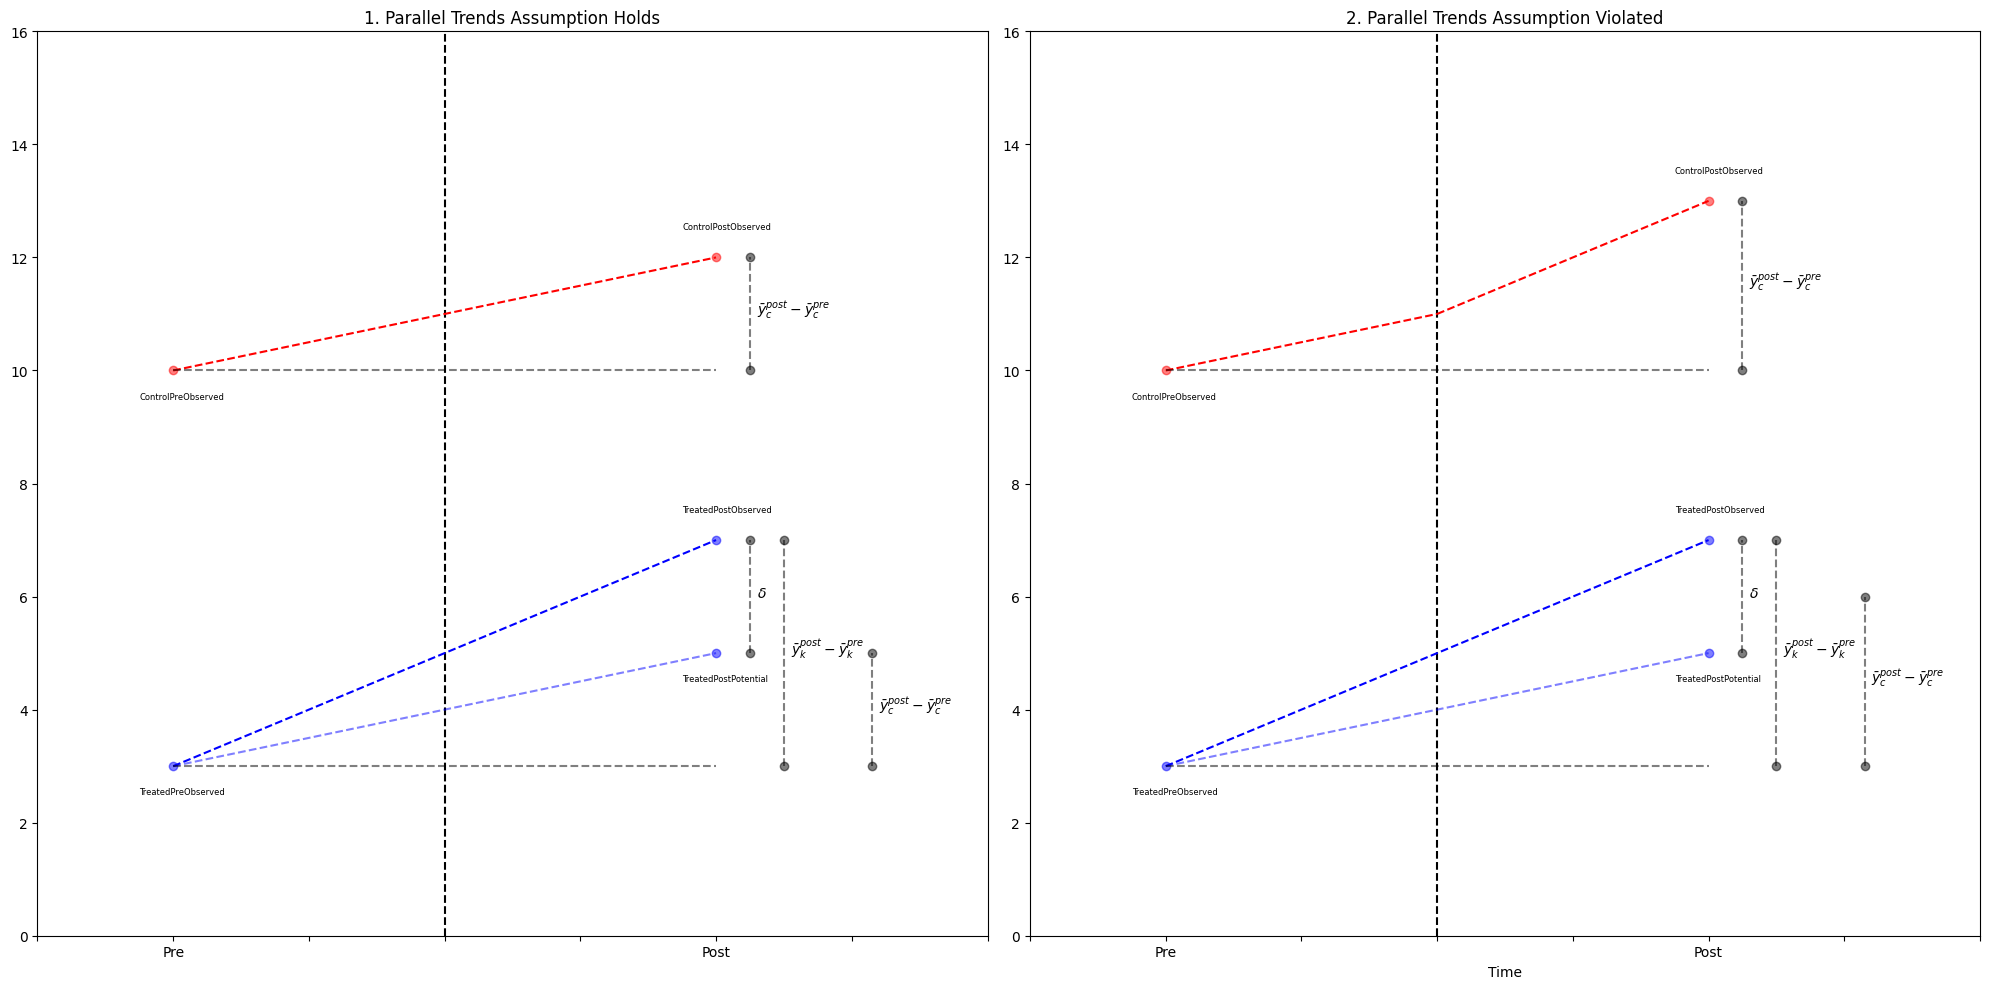

In [2]:
# Here I want to make a plot that I can annotate to graphically illustrate DiD
# I also want to make a plot that shows graphically what happens to our estimate if we violate the parallel trends assumption
pre = 2
post = 10
treatment = 6

treated_pre = 3
control_pre = 10

treated_post_observed = 7
treated_post_potential = 5
control_post_observed = 12
control_post_observed_non_paralell = 13

fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].set_xlim(0, 14)
ax[0].set_ylim(0, 16)
ax[0].axvline(x=treatment, color='black', linestyle='--', label='Treatment')
ax[0].set_xticklabels(['', 'Pre', '', '', '', 'Post'])
ax[1].set_xlim(0, 14)
ax[1].set_ylim(0, 16)
ax[1].axvline(x=treatment, color='black', linestyle='--', label='Treatment')
ax[1].set_xticklabels(['', 'Pre', '', '', '', 'Post'])
ax[1].set_xlabel('Time')

ax[0].plot(pre, treated_pre, marker='o', alpha=0.5, color='blue')
ax[0].annotate('TreatedPreObserved', xy=(pre, treated_pre), xytext=(pre - 0.5, treated_pre - 0.5), fontsize=6)
ax[0].plot(post, treated_post_observed, marker='o', alpha=0.5, color='blue')
ax[0].annotate('TreatedPostObserved', xy=(post, treated_post_observed), xytext=(post - 0.5, treated_post_observed + 0.5), fontsize=6)
ax[0].plot(post, treated_post_potential, marker='o', alpha=0.5, color='blue')
ax[0].annotate('TreatedPostPotential', xy=(post, treated_post_potential), xytext=(post - 0.5, treated_post_potential - 0.5), fontsize=6)
ax[0].plot([pre, post], [treated_pre, treated_post_observed], color='blue', linestyle='--')
ax[0].plot([pre, post], [treated_pre, treated_post_potential], color='blue', alpha=0.5, linestyle='--')
ax[0].plot(pre, control_pre, marker='o', alpha=0.5, label='ControlPreObserved', color='Red')
ax[0].annotate('ControlPreObserved', xy=(pre, control_pre), xytext=(pre - 0.5, control_pre - 0.5), fontsize=6)
ax[0].plot(post, control_post_observed, marker='o', alpha=0.5, color='Red')
ax[0].annotate('ControlPostObserved', xy=(post, control_post_observed), xytext=(post - 0.5, control_post_observed + 0.5), fontsize=6)
ax[0].plot([pre, post], [control_pre, control_post_observed], color='Red', linestyle='--')

ax[0].plot([post+0.5, post+0.5], [treated_post_potential, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\delta$', xy=(post+0.5, (treated_post_observed + treated_post_potential) / 2), xytext=(post + 0.6, (treated_post_observed + treated_post_potential) / 2), fontsize=10)

ax[0].plot([pre, post], [control_pre, control_pre], color='black', linestyle='--', alpha=0.5)
ax[0].plot([post+0.5, post+0.5], [control_pre, control_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+0.5, (control_post_observed + control_pre) / 2), xytext=(post + 0.6, (control_post_observed + control_pre) / 2), fontsize=10)

ax[0].plot([pre, post], [treated_pre, treated_pre], color='black', linestyle='--', alpha=0.5)
ax[0].plot([post+1, post+1], [treated_pre, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\bar{y}_{k}^{post} - \\bar{y}_{k}^{pre}$', xy=(post+1, (treated_post_observed + treated_pre) / 2), xytext=(post + 1.1, (treated_post_observed + treated_pre) / 2), fontsize=10)
ax[0].plot([post+2.3, post+2.3], [treated_pre, treated_post_potential], color='black', marker='o', linestyle='--', alpha=0.5)
ax[0].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+2.3, (treated_pre + treated_post_potential) / 2), xytext=(post + 2.4, (treated_pre + treated_post_potential) / 2), fontsize=10)

ax[0].set_title('1. Parallel Trends Assumption Holds')


ax[1].plot(pre, treated_pre, marker='o', alpha=0.5, color='blue')
ax[1].annotate('TreatedPreObserved', xy=(pre, treated_pre), xytext=(pre - 0.5, treated_pre - 0.5), fontsize=6)
ax[1].plot(post, treated_post_observed, marker='o', alpha=0.5, color='blue')
ax[1].annotate('TreatedPostObserved', xy=(post, treated_post_observed), xytext=(post - 0.5, treated_post_observed + 0.5), fontsize=6)
ax[1].plot(post, treated_post_potential, marker='o', alpha=0.5, color='blue')
ax[1].annotate('TreatedPostPotential', xy=(post, treated_post_potential), xytext=(post - 0.5, treated_post_potential - 0.5), fontsize=6)
ax[1].plot([pre, post], [treated_pre, treated_post_observed], color='blue', linestyle='--')
ax[1].plot([pre, post], [treated_pre, treated_post_potential], color='blue', alpha=0.5, linestyle='--')
ax[1].plot(pre, control_pre, marker='o', alpha=0.5, label='ControlPreObserved', color='Red')
ax[1].annotate('ControlPreObserved', xy=(pre, control_pre), xytext=(pre - 0.5, control_pre - 0.5), fontsize=6)
ax[1].plot(post, control_post_observed_non_paralell, marker='o', alpha=0.5, color='Red')
ax[1].annotate('ControlPostObserved', xy=(post, control_post_observed_non_paralell), xytext=(post - 0.5, control_post_observed_non_paralell + 0.5), fontsize=6)
ax[1].plot([pre, treatment], [control_pre, (control_pre + control_post_observed)/2], color='Red', linestyle='--')
ax[1].plot([treatment, post], [ (control_pre + control_post_observed)/2, control_post_observed_non_paralell], color='Red', linestyle='--')

ax[1].plot([post+0.5, post+0.5], [treated_post_potential, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\delta$', xy=(post+0.5, (treated_post_observed + treated_post_potential) / 2), xytext=(post + 0.6, (treated_post_observed + treated_post_potential) / 2), fontsize=10)

ax[1].plot([pre, post], [control_pre, control_pre], color='black', linestyle='--', alpha=0.5)
ax[1].plot([post+0.5, post+0.5], [control_pre, control_post_observed_non_paralell], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+0.5, (control_post_observed_non_paralell + control_pre) / 2), xytext=(post + 0.6, (control_post_observed_non_paralell + control_pre) / 2), fontsize=10)

ax[1].plot([pre, post], [treated_pre, treated_pre], color='black', linestyle='--', alpha=0.5)
ax[1].plot([post+1, post+1], [treated_pre, treated_post_observed], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\bar{y}_{k}^{post} - \\bar{y}_{k}^{pre}$', xy=(post+1, (treated_post_observed + treated_pre) / 2), xytext=(post + 1.1, (treated_post_observed + treated_pre) / 2), fontsize=10)
ax[1].plot([post+2.3, post+2.3], [treated_pre, treated_pre + (control_post_observed_non_paralell - control_pre)], color='black', marker='o', linestyle='--', alpha=0.5)
ax[1].annotate('$\\bar{y}_{c}^{post} - \\bar{y}_{c}^{pre}$', xy=(post+2.3, (treated_pre + (control_post_observed_non_paralell - control_pre)/2)), xytext=(post + 2.4, (treated_pre + (control_post_observed_non_paralell - control_pre) / 2)), fontsize=10)

ax[1].set_title('2. Parallel Trends Assumption Violated')

plt.tight_layout()
plt.show()

Some explantation

## Load Data

The organ_donation data contains data from Kessler and Roth (2014) on organ donation rates by state and quarter. The state of California enacted an active-choice phrasing for their organ donation sign-up questoin in Q32011. The only states included in the data are California and those that can serve as valid controls; see Kessler and Roth (2014).

Below we plot the donation rate for each state by quarter with the donation rate for California highlighted in blue. We see that the average donation rate in the quarters after the policy is lower. However, this does not mean that the policy caused the rate drop, we need to account for the effect of time. We can see the effect of time by looking at the average donation rate for the rest of the states in the US. We notice that the average rate is slightly higher, if we assume California would have followed this trend (paralell trends assumption) the estimated impact of the policy will be negative. (see the estimation section below) 

In [3]:
# Load data
df = organ_donations.load_pandas().data
df['Year'] = df['Quarter'].str[2:].astype(int)
df.head()

,State,Quarter,Rate,Quarter_Num,Year
0,Alaska,Q42010,0.75,1,2010
1,Alaska,Q12011,0.77,2,2011
2,Alaska,Q22011,0.77,3,2011
3,Alaska,Q32011,0.78,4,2011
4,Alaska,Q42011,0.78,5,2011


In [4]:
california = df[df['State'] == 'California']
rest_of_us = df[df['State'] != 'California']

In [5]:
before_treatment_cali_avg = california[california['Quarter_Num'] <= 3]['Rate'].mean()
before_treatment_rest_avg = rest_of_us[rest_of_us['Quarter_Num'] <= 3]['Rate'].mean()
after_treatment_cali_avg = california[california['Quarter_Num'] > 3]['Rate'].mean()
after_treatment_rest_avg = rest_of_us[rest_of_us['Quarter_Num'] > 3]['Rate'].mean()

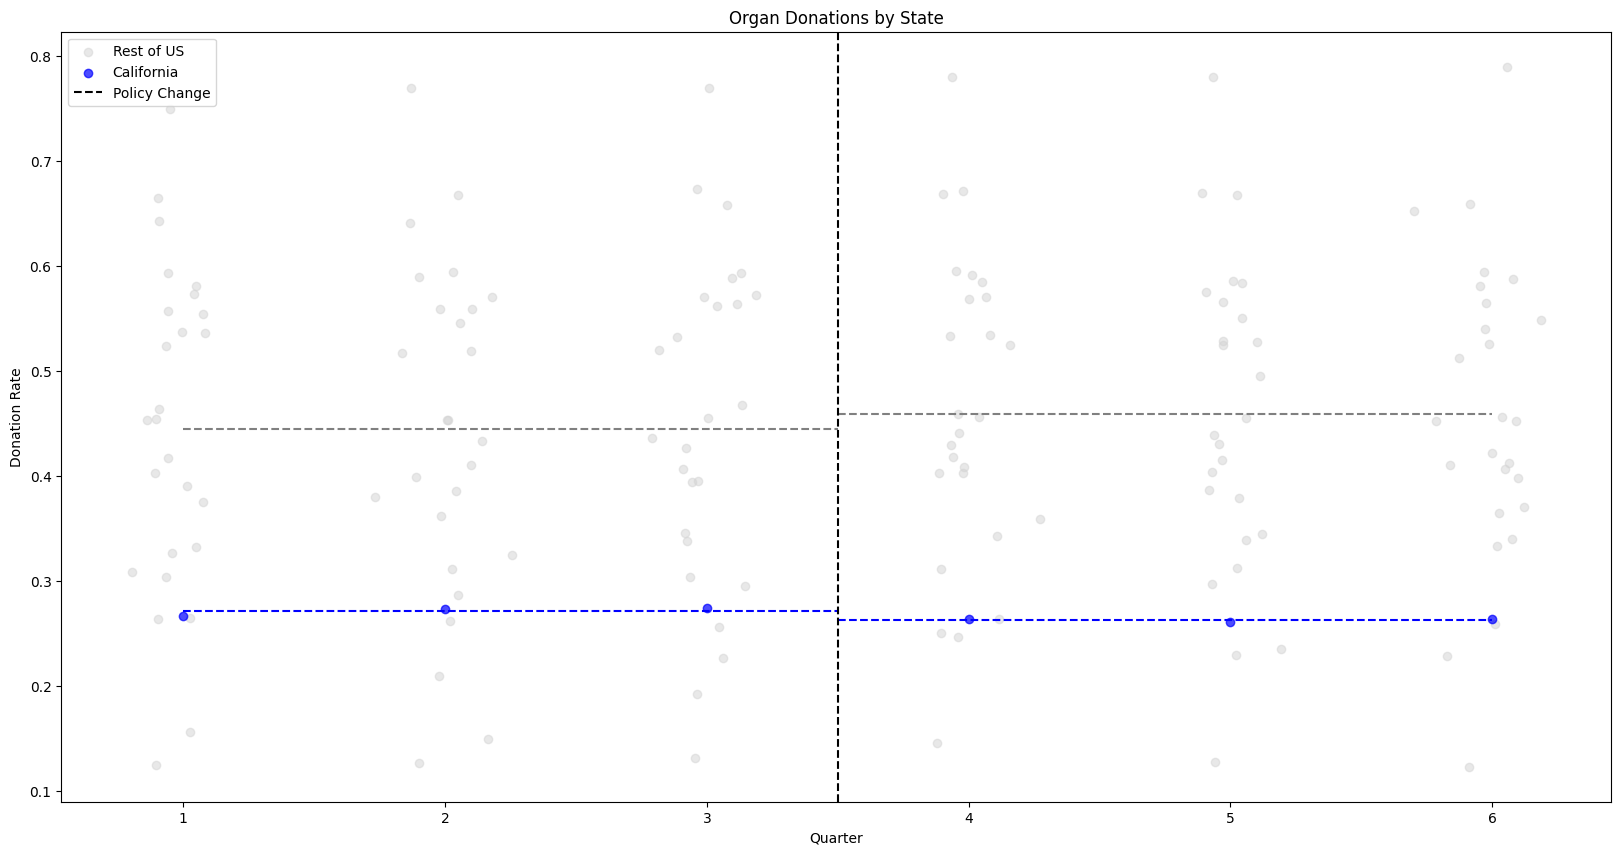

In [6]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.scatter(rest_of_us['Quarter_Num'] + np.random.normal(0, 0.1, len(rest_of_us)), rest_of_us['Rate'], color='lightgray', label='Rest of US', alpha=0.5)
ax.scatter(california['Quarter_Num'], california['Rate'], color='blue', label='California', alpha=0.7)

ax.plot([1, 3.5], [before_treatment_rest_avg, before_treatment_rest_avg], color='gray', linestyle='--')
ax.plot([3.5, 6], [after_treatment_rest_avg, after_treatment_rest_avg], color='gray', linestyle='--')

ax.plot([1, 3.5], [before_treatment_cali_avg, before_treatment_cali_avg], color='blue', linestyle='--')
ax.plot([3.5, 6], [after_treatment_cali_avg, after_treatment_cali_avg], color='blue', linestyle='--')
ax.axvline(x=3.5, label='Policy Change', linestyle='--', color='black')
ax.set_xlabel('Quarter')
ax.set_ylabel('Donation Rate')
ax.set_title('Organ Donations by State')
ax.legend()


## Estimation

From above it is clear that we can get the TWFE estimate using only simple atrithmetic. This is shown below and using this method we estimate that the implementation of active choice reduced the organ dontation rate by $2ppts$. However, whilst simple to implement, if we estimate using arithmetic we do not get any indication of the uncertainty of our estimate. This is why the TWFE is implemented using regression. The regression model is

$$
Y = \beta_{0} + \beta_{1}Treated + \beta_{2}After + \beta_{3}Treated*After
$$

In this model $\beta_{3}$, the coefficient of the interaction term is our estimate for the impact of treatment. To see why consider the following partial derivatives (these are binary variables so there are no real derivatives but it is helpful to use the notation)

$$
\frac{\partial{Y}}{\partial{Treated}} = \beta_{1} + \beta_{3}After
$$

$$
\frac{\partial{Y}}{\partial{After}} = \beta_{2} + \beta_{3}Treated
$$

$$
\frac{\partial^{2} {Y}}{\partial{Treated}\partial{After}} = \beta_{3}
$$

From the first derivative we can see that $\beta_{1}$ tells us the difference in donation rates between California and the rest of the US in the period before treatment. Similarly the second derivative shows that $\beta_{2}$ is the change over time in the control states, this captures the time fixed effect in organ donation rates. Finally, this leaves $\beta_{3}$ which is only active in the model when both $Treated=1$ and $After=1$ and therefore it captures the effect of the treatment on the organ donation rate in California, controlling for California's fixed effect and the time fixed effect (of course this still assumes that California would have followed the same trend as the rest of the US had the policy not been enacted).

If we look at our regression results we can see that the estimated treatment effect is a reduction in the donation rate by $2ppts$. We use cluster robust standard errors, this allows the calculation to account for the fact that values across states are highly correlated. The standard error is $0.6ppts$ and the p-value is tiny. This gives strong support to the hypothesis that active choice has a non-zero impact on the organ donation rate

In [17]:
california_diff = after_treatment_cali_avg - before_treatment_cali_avg
rest_diff = after_treatment_rest_avg - before_treatment_rest_avg
diff_in_diff_arithmetic_estimate = california_diff - rest_diff

print(f"Estimated effect of policy change on organ donation rate in California: {diff_in_diff_arithmetic_estimate:.4f}")

Estimated effect of policy change on organ donation rate in California: -0.0225


In [18]:
reg1_df = pd.DataFrame({
    'Rate': df['Rate'],
    'Treated': (df['State'] == 'California').astype(int),
    'Post': (df['Quarter_Num'] > 3).astype(int),
    'Treated:Post': ((df['State'] == 'California') & (df['Quarter_Num'] > 3)).astype(int)
})

reg1 = sm.OLS(reg1_df['Rate'], sm.add_constant(reg1_df[['Treated', 'Post', 'Treated:Post']])).fit(cov_type='cluster', cov_kwds={'groups': df['State']})  # Using cluster-robust standard errors

reg1.summary()

c:\Users\caine\Documents\causal-inference\venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   Rate   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     32.82
Date:                Tue, 11 Aug 2026   Prob (F-statistic):           7.73e-08
Time:                        10:47:59   Log-Likelihood:                 78.895
No. Observations:                 162   AIC:                            -149.8
Df Residuals:                     158   BIC:                            -137.4
Df Model:                           3                                         
Covariance Type:              cluster                                         
================================================================================
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.4449      0.031     14.171      0.000       0.383       0.506
Treated         -0.1736      0.031     -5.529      0.000      -0.235      -0.112
Post             0.0139      0.006      2.293      0.022       0.002       0.026
Treated:Post    -0.0225      0.006     -3.698      0.000      -0.034      -0.011
==============================================================================
Omnibus:                        0.962   Durbin-Watson:                   0.309
Prob(Omnibus):                  0.618   Jarque-Bera (JB):                1.035
Skew:                          -0.106   Prob(JB):                        0.596
Kurtosis:                       2.670   Cond. No.                         13.9
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

## Placebo Tests

Below we implement placebo tests as a way to refute our methodology. What we are going to do is the remove the data after treatment and pretend that treatment happend earlier than it did. Then we will fit the TWFE and check the results. As there was no treatment we should see no effect if paralell trends holds for the periods after our fake treatment date. If we identify an effect then we have some explaining to do as to why we assume paralell trends holds after the actual treatment date. As with all placebo tests, this does not show that our assumptions hold. However, the point is that if the placebo tests fails and we see treatment effects everywhere, then this is evidence that our assumptions probably dont hold.

In [ ]:
placebo_df = pd.DataFrame({
    'Rate': df[df['Quarter_Num'] <= 3]['Rate'],
    'Treated': (df[df['Quarter_Num'] <= 3]['State'] == 'California').astype(int),
    'FakeAfter1': (df[df['Quarter_Num'] <= 3]['Quarter_Num'] > 2).astype(int),
    'FakeAfter2': (df[df['Quarter_Num'] <= 3]['Quarter_Num'] > 1).astype(int),
})

## Bibliography

Kessler & Roth (2014)